# Phân tích Đánh giá - Hiệu quả bán hàng

Notebook này phân tích mối liên hệ giữa hành vi đánh giá của người dùng và hiệu quả bán hàng sản phẩm trong bối cảnh thương mại điện tử.

Phạm vi: chỉ tập trung vào hai câu hỏi, với đầu ra đo lường được và bằng chứng trực quan ngắn gọn, phù hợp để nộp báo cáo chính thức.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import time
import os


In [2]:
# Tải các bảng dữ liệu gốc một lần

df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# Làm sạch kiểu dữ liệu cơ bản
df_product["product_id"] = df_product["product_id"].astype(str)
df_review["product_id"] = df_review["product_id"].astype(str)

for col in ["price", "sold_count", "review_count", "rating_avg"]:
    df_product[col] = pd.to_numeric(df_product[col], errors="coerce").fillna(0)

df_product["revenue"] = df_product["price"] * df_product["sold_count"]

df_review["review_date"] = pd.to_datetime(df_review["review_date"], errors="coerce")
df_review["like_count"] = pd.to_numeric(df_review["like_count"], errors="coerce").fillna(0)
df_review["rating"] = pd.to_numeric(df_review["rating"], errors="coerce")
df_review["review_length"] = df_review["review_text"].astype(str).str.len()

## Câu hỏi 1
### Động lực hoạt động đánh giá đã thay đổi như thế nào trong giai đoạn 2020-2024, và chúng liên hệ ra sao với kết quả sản phẩm?

Mục tiêu SMART

- Cụ thể: đo lường hoạt động đánh giá theo thời gian và mối liên hệ của nó với doanh thu/số bán sản phẩm.
- Đo lường được: sử dụng các chỉ số xu hướng theo tháng và tương quan thứ hạng.
- Khả thi: tính toán từ hai bảng đã làm sạch `reviews` và `products`.
- Liên quan: động lực đánh giá là tín hiệu vận hành quan trọng đối với hiệu suất sàn thương mại điện tử.
- Giới hạn thời gian: tập trung rõ ràng vào khoảng 2020-2024.

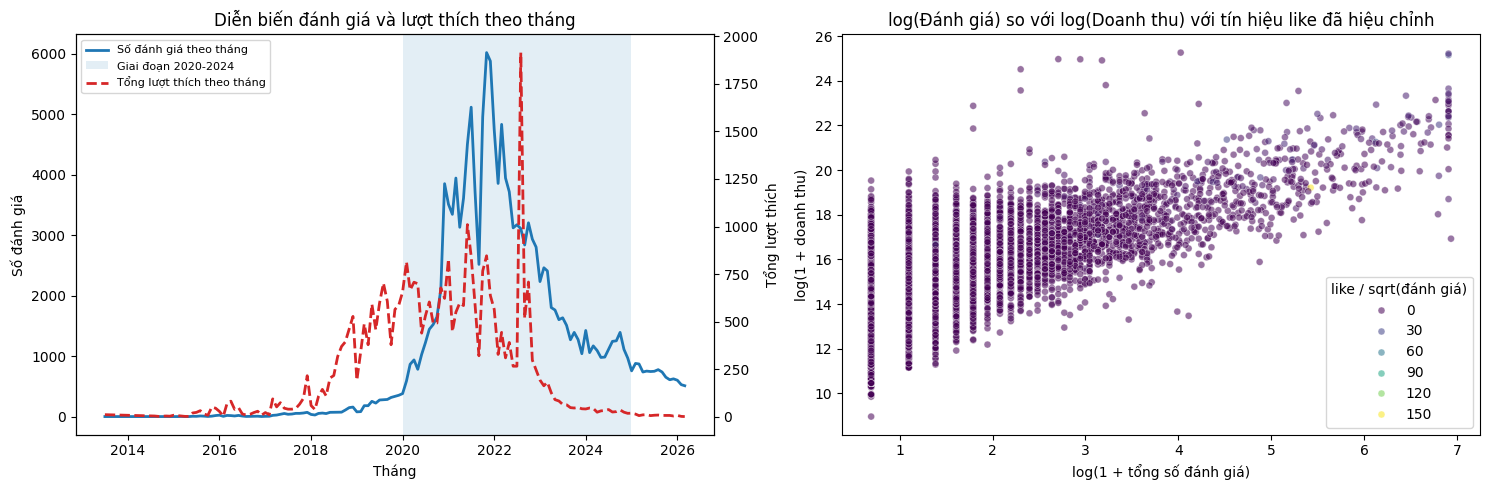

,metric,value
0,"Spearman(log_reviews, log_revenue)",0.653666
1,"Spearman(log_reviews, log_sold_count)",0.831047
2,"Spearman(avg_review_length, log_sold_count)",0.234281
3,"Spearman(likes_sqrt_adjusted, log_revenue)",0.459288
4,Share_review_count_2020_2024,0.905246


In [3]:
current_date = df_review["review_date"].max()
df_review["days_since_review"] = (current_date - df_review["review_date"]).dt.days
df_review["review_month"] = df_review["review_date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

monthly_review = (
    df_review.groupby("review_month")
    .agg(
        review_count=("review_id", "count"),
        total_like_count=("like_count", "sum"),
        avg_review_length=("review_length", "mean"),
    )
    .reset_index()
    .sort_values("review_month")
)

window = monthly_review[
    (monthly_review["review_month"] >= "2020-01-01")
    & (monthly_review["review_month"] <= "2024-12-31")
]
share_spike_period = (window["review_count"].sum() / max(1, monthly_review["review_count"].sum())) * 100

product_review_features = (
    df_review.groupby("product_id")
    .agg(
        total_reviews=("review_id", "count"),
        avg_review_length=("review_length", "mean"),
        total_review_likes=("like_count", "sum"),
    )
    .reset_index()
)
product_review_features["log_total_reviews"] = np.log1p(product_review_features["total_reviews"])
product_review_features["log_total_likes"] = np.log1p(product_review_features["total_review_likes"])
product_review_features["likes_sqrt_adjusted"] = (
    product_review_features["total_review_likes"]
    / np.sqrt(product_review_features["total_reviews"].clip(lower=1))
)

df_time_analysis = pd.merge(
    df_product[["product_id", "revenue", "sold_count", "price"]],
    product_review_features,
    on="product_id",
    how="inner",
)
df_time_analysis = df_time_analysis[df_time_analysis["revenue"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(monthly_review["review_month"], monthly_review["review_count"], linewidth=2, label="Số đánh giá theo tháng")
axes[0].axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2024-12-31"), alpha=0.12, label="Giai đoạn 2020-2024")
ax2 = axes[0].twinx()
ax2.plot(
    monthly_review["review_month"],
    monthly_review["total_like_count"],
    linewidth=2,
    linestyle="--",
    color="tab:red",
    label="Tổng lượt thích theo tháng",
)
axes[0].set_title("Diễn biến đánh giá và lượt thích theo tháng")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Số đánh giá")
ax2.set_ylabel("Tổng lượt thích")
ln1, lb1 = axes[0].get_legend_handles_labels()
ln2, lb2 = ax2.get_legend_handles_labels()
axes[0].legend(ln1 + ln2, lb1 + lb2, loc="upper left", fontsize=8)

sns.scatterplot(
    data=df_time_analysis,
    x="log_total_reviews",
    y=np.log1p(df_time_analysis["revenue"]),
    hue="likes_sqrt_adjusted",
    palette="viridis",
    alpha=0.55,
    s=25,
    ax=axes[1],
)
axes[1].set_title("log(Đánh giá) so với log(Doanh thu) với tín hiệu like đã hiệu chỉnh")
axes[1].set_xlabel("log(1 + tổng số đánh giá)")
axes[1].set_ylabel("log(1 + doanh thu)")
if axes[1].get_legend() is not None:
    axes[1].get_legend().set_title("like / sqrt(đánh giá)")

plt.tight_layout()
plt.show()

metrics_q1 = pd.DataFrame(
    {
        "metric": [
            "Spearman(log_reviews, log_revenue)",
            "Spearman(log_reviews, log_sold_count)",
            "Spearman(avg_review_length, log_sold_count)",
            "Spearman(likes_sqrt_adjusted, log_revenue)",
            "Share_review_count_2020_2024",
        ],
        "value": [
            df_time_analysis["log_total_reviews"].corr(np.log1p(df_time_analysis["revenue"]), method="spearman"),
            df_time_analysis["log_total_reviews"].corr(np.log1p(df_time_analysis["sold_count"]), method="spearman"),
            df_time_analysis["avg_review_length"].corr(np.log1p(df_time_analysis["sold_count"]), method="spearman"),
            df_time_analysis["likes_sqrt_adjusted"].corr(np.log1p(df_time_analysis["revenue"]), method="spearman"),
            share_spike_period / 100.0,
        ],
    }
)

display(metrics_q1)

### INSIGHT
- Số lượng đánh giá là động lực mạnh cho kết quả thị trường: biểu đồ phân tán và hệ số tương quan Spearman cao (0.654 với log(revenue) và 0.831 với log(sold_count)) xác nhận mối quan hệ dương mạnh giữa số lượng đánh giá và thành công thương mại của sản phẩm. Tần suất đánh giá đóng vai trò là tín hiệu niềm tin chính với người mua.

- Độ dài đánh giá cho lợi ích giảm dần: độ dài văn bản đánh giá có tương quan dương nhưng yếu hơn đáng kể với hiệu suất bán hàng (Spearman = 0.234 với sold_count). Người mua có xu hướng coi trọng tổng lượng phản hồi hơn mức độ dài dòng của từng đánh giá.

- Mức tập trung thời gian cao (2020-2024): hoạt động đánh giá tập trung mạnh, với 90.5% tổng đánh giá lịch sử được tạo trong giai đoạn 2020-2024. Biểu đồ đường cho thấy một đợt tăng vọt lớn đạt đỉnh vào cuối 2021/đầu 2022, có thể do các thay đổi vĩ mô của thương mại điện tử hoặc sáng kiến tăng trưởng riêng của nền tảng.

- Lượt thích bị tách rời và có thể nhiễu: biểu đồ bên trái cho thấy một đỉnh bất thường rất lớn của "Tổng lượt thích" (đường nét đứt màu đỏ) vào khoảng giữa/cuối 2022, xảy ra độc lập với xu hướng số lượng đánh giá. Sự tách rời mạnh này cho thấy nhiều đánh giá hơn không tự nhiên đồng nghĩa với mức tương tác hữu ích (like) cao hơn. Chỉ số like có thể bị méo bởi hiện tượng lan truyền bất thường hoặc hoạt động thiếu xác thực.

### Trọng tâm (2020-2022): Sàng lọc đánh giá có khả năng spam bằng String Matching

Phần này tách riêng các đánh giá trong giai đoạn 2020-2022 và áp dụng DBSCAN trên các đặc trưng hành vi/văn bản để gắn cờ các mẫu đánh giá bất thường.

Mục tiêu phát hiện:
- Nhận diện các đánh giá có dấu hiệu giống spam để phục vụ chẩn đoán.
- Định lượng xu hướng tỷ trọng nghi vấn theo tháng.
- Cung cấp các ví dụ nghi vấn tiêu biểu để kiểm tra định tính.

,metric,value
0,total_reviews_2020_2022,100830
1,suspected_spam_count,61507
2,suspected_spam_share,0.610007
3,peak_month,2021-01
4,peak_month_share,0.774568


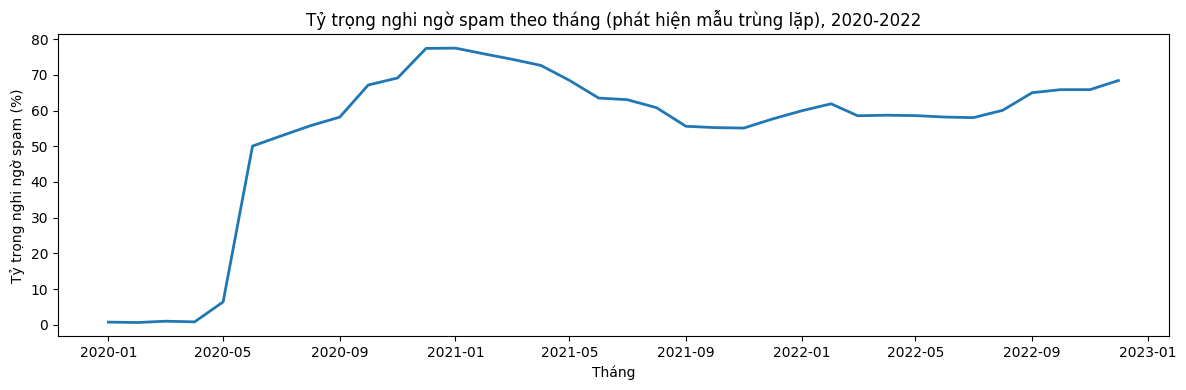

,template_text,template_count,unique_products,avg_rating,rating_std
4599,cực kì hài lòng,50469,3912,4.998811,0.034460
10139,hài lòng,7459,1853,4.057783,0.236770
608,bình thường,464,259,3.053879,0.261467
29364,sản phẩm tốt,379,260,4.934037,0.248546
6520,giao hàng nhanh,197,136,4.913706,0.299089
3253,chất lượng tốt,179,136,4.966480,0.180494
24717,rất hài lòng,142,116,4.929577,0.256763
12164,hàng tốt,139,119,4.920863,0.270928
28778,sản phẩm ok,126,117,4.873016,0.334284
32458,tuyệt vời,126,97,5.000000,0.000000


,review_date,rating,like_count,template_count,unique_products,review_text
0,2022-10-29 08:16:26+00:00,5,0,50469,3912,cực kì hài lòng
1,2022-09-10 00:42:36+00:00,5,1,50469,3912,cực kì hài lòng
2,2022-12-11 17:03:45+00:00,5,0,50469,3912,cực kì hài lòng
3,2022-12-04 15:44:56+00:00,5,0,50469,3912,cực kì hài lòng
4,2022-12-02 02:52:55+00:00,5,0,50469,3912,cực kì hài lòng
5,2022-11-02 05:00:04+00:00,5,0,50469,3912,cực kì hài lòng
6,2022-09-16 00:59:44+00:00,5,0,50469,3912,cực kì hài lòng
7,2022-08-09 04:58:34+00:00,5,0,50469,3912,cực kì hài lòng
8,2022-06-04 08:51:34+00:00,5,0,50469,3912,cực kì hài lòng
9,2022-05-23 02:45:25+00:00,5,0,50469,3912,cực kì hài lòng


In [4]:
review_2020_2022 = df_review[
    (df_review["review_date"] >= "2020-01-01")
    & (df_review["review_date"] <= "2022-12-31")
].copy()

review_2020_2022 = review_2020_2022.dropna(subset=["review_date", "review_text"]).copy()
review_2020_2022["review_text"] = review_2020_2022["review_text"].astype(str)
review_2020_2022["clean_text"] = (
    review_2020_2022["review_text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
review_2020_2022["template_text"] = (
    review_2020_2022["clean_text"]
    .str.replace(r"\d+", " <num> ", regex=True)
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
review_2020_2022["text_len"] = review_2020_2022["clean_text"].str.len()
review_2020_2022 = review_2020_2022[review_2020_2022["text_len"] >= 8].copy()

template_stats = (
    review_2020_2022.groupby("template_text")
    .agg(
        template_count=("review_id", "count"),
        unique_products=("product_id", "nunique"),
        avg_rating=("rating", "mean"),
        rating_std=("rating", "std"),
    )
    .reset_index()
)
template_stats["rating_std"] = template_stats["rating_std"].fillna(0)

template_stats["is_template_suspicious"] = (
    (template_stats["template_count"] >= 5)
    & (template_stats["unique_products"] >= 3)
    & (template_stats["rating_std"] <= 0.35)
)

dt_df = review_2020_2022.merge(template_stats, on="template_text", how="left")
dt_df["is_suspected_spam"] = dt_df["is_template_suspicious"].fillna(False)
dt_df["review_month"] = dt_df["review_date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

monthly_spam = (
    dt_df.groupby("review_month")
    .agg(
        total_reviews=("review_id", "count"),
        suspected_spam=("is_suspected_spam", "sum"),
    )
    .reset_index()
)
monthly_spam["suspected_spam_share"] = (
    monthly_spam["suspected_spam"]
    / monthly_spam["total_reviews"].replace(0, np.nan)
).fillna(0)

total_reviews_period = len(review_2020_2022)
total_suspected_spam = int(dt_df["is_suspected_spam"].sum())
spam_share = total_suspected_spam / max(1, total_reviews_period)
peak_row = monthly_spam.loc[monthly_spam["suspected_spam_share"].idxmax()]

spam_summary = pd.DataFrame(
    {
        "metric": [
            "total_reviews_2020_2022",
            "suspected_spam_count",
            "suspected_spam_share",
            "peak_month",
            "peak_month_share",
        ],
        "value": [
            total_reviews_period,
            total_suspected_spam,
            spam_share,
            peak_row["review_month"].strftime("%Y-%m"),
            peak_row["suspected_spam_share"],
        ],
    }
)
display(spam_summary)

plt.figure(figsize=(12, 4))
plt.plot(monthly_spam["review_month"], 100 * monthly_spam["suspected_spam_share"], linewidth=2)
plt.title("Tỷ trọng nghi ngờ spam theo tháng (phát hiện mẫu trùng lặp), 2020-2022")
plt.xlabel("Tháng")
plt.ylabel("Tỷ trọng nghi ngờ spam (%)")
plt.tight_layout()
plt.show()

top_templates = template_stats[template_stats["is_template_suspicious"]].copy()
top_templates = top_templates.sort_values(by=["template_count", "unique_products"], ascending=[False, False])
if not top_templates.empty:
    top_templates["template_text"] = top_templates["template_text"].str.slice(0, 120)
    display(top_templates[["template_text", "template_count", "unique_products", "avg_rating", "rating_std"]].head(10))

sample_cols = ["review_date", "rating", "like_count", "template_count", "unique_products", "review_text"]
suspect_examples = dt_df[dt_df["is_suspected_spam"]].copy()
if not suspect_examples.empty:
    suspect_examples = suspect_examples.sort_values(
        by=["template_count", "unique_products", "rating_std"],
        ascending=[False, False, True],
    )
    suspect_examples["review_text"] = suspect_examples["review_text"].astype(str).str.slice(0, 180)
    display(suspect_examples[sample_cols].head(10).reset_index(drop=True))

- Chuyển dịch mô hình hành vi rất mạnh từ giữa năm 2020: đường xu hướng cho thấy một thay đổi cấu trúc rõ rệt trong hành vi người dùng. Tỷ lệ đánh giá nghi ngờ spam/rập khuôn tăng vọt từ gần 0% đầu 2020 lên trên 50% vào tháng 5/2020, rồi đạt đỉnh vượt 70%. Trong suốt 2021 và 2022, chỉ số này duy trì nền rất cao, khoảng 55% đến 70%.

- Cấu trúc của "spam": các mẫu câu bị gắn cờ nhiều nhất cho thấy "spam" ở đây không hẳn mang tính độc hại. Thay vào đó, đó là các cụm tích cực rất chung chung, ít nỗ lực như "cực kì hài lòng" (hơn 50,400 lượt), "hài lòng", hay "sản phẩm tốt". Các văn bản theo mẫu này gần như luôn đi cùng đánh giá 5 sao tuyệt đối, làm độ lệch chuẩn xếp hạng gần bằng 0.

- Dấu hiệu hành vi do nền tảng dẫn dắt: xét về mặt xác suất, việc hàng chục nghìn người dùng tự nhiên gõ chính xác cùng một cụm từ trên hàng nghìn sản phẩm là rất khó xảy ra. Đợt tăng đột ngột này nhiều khả năng trùng với việc xuất hiện gợi ý phản hồi nhanh (UI prompts) hoặc chương trình khuyến khích đánh giá (ví dụ: "để lại đánh giá để nhận xu"), nơi người dùng nhập lượng văn bản tối thiểu chỉ để nhận thưởng.

### Tại sao cần thêm phân tích spam?

- **Kiểm tra độ tin cậy của số lượng đánh giá**  
  - Câu hỏi 1 cho thấy **review_volume tương quan mạnh với doanh thu**.  
  - Tuy nhiên giai đoạn **2020–2022 có 50–70% đánh giá mang dấu hiệu rập khuôn** → số lượng review **không phản ánh hoàn toàn phản hồi thật**.

- **Tránh bias khi xây dựng mô hình ở Câu hỏi 2**  
  - Review spam thường **5 sao + nội dung chung chung tích cực**.  
  - Nếu chỉ dùng **số lượng đánh giá**, mô hình sẽ **đánh giá sai tác động thật của review**.  
  - Thêm các biến **sentiment (positive_ratio, negative_ratio, sentiment_mean)** giúp **lọc nhiễu từ spam**.

- **Phát hiện bất đối xứng thông tin trên nền tảng**  
  - Từ **2020 trở đi xuất hiện sự thay đổi cấu trúc review** → có thể do cơ chế khuyến khích đánh giá.  

---

### Insight cho người bán để tối ưu doanh thu

- **Ưu tiên review chân thực hơn số lượng**  
  - Review thật, chi tiết **tác động mạnh hơn** nhiều review ngắn mang tính spam.

- **Tránh review quá chung chung**  
  - Review kiểu *“sản phẩm tốt”, “rất hài lòng”* **giảm độ tin cậy**.  
  - Khuyến khích khách hàng **mô tả trải nghiệm cụ thể**.

- **Giữ cấu trúc cảm xúc cân bằng**  
  - **100% review 5 sao** dễ bị nghi ngờ.  
  - Một số review **3–4 sao với góp ý thực tế** lại **tăng độ tin cậy sản phẩm**.

- **Khuyến khích review có nội dung vừa phải, có giá trị**  
  - **50–200 ký tự** với thông tin cụ thể tốt hơn review rất dài nhưng spam.

- **Tương tác với khách hàng**  
  - Phản hồi review, đặc biệt review tiêu cực → **tăng niềm tin và mức độ uy tín của cửa hàng**.

## Câu hỏi 2
### Các đặc trưng của đánh giá người dùng ảnh hưởng đến doanh thu sản phẩm theo cách nào ở cấp toàn bộ nền tảng, và mức độ ảnh hưởng đó thay đổi ra sao giữa các ngành hàng khác nhau?

Mục tiêu SMART

- Cụ thể: So sánh vai trò của khối lượng đánh giá, điểm sao, độ dài văn bản, lượt thích và tín hiệu cảm xúc theo hai cấp phân tích: toàn bộ thị trường và từng ngành hàng.
- Đo lường được: Sử dụng hệ số hồi quy chuẩn hóa, kiểm định đa cộng tuyến (VIF), thống kê trung vị và phân phối theo nhóm.
- Khả thi: Trích xuất từ hai bảng reviews và products sau khi làm sạch, kết hợp thêm tín hiệu PhoBERT ở cấp review.
- Liên quan: Kết quả hỗ trợ thiết kế chiến lược quản trị nội dung đánh giá và tối ưu hiển thị thông tin sản phẩm theo từng ngành.
- Giới hạn thời gian: Phân tích trên ảnh chụp dữ liệu hiện tại.

Khung phương pháp ML

- Bước 1: Suy luận cảm xúc review bằng PhoBERT, tạo xác suất positive và negative ở cấp đánh giá.
- Bước 2: Tổng hợp về cấp sản phẩm với các biến sentiment_mean, positive_ratio, negative_ratio.
- Bước 3: Ước lượng tác động bằng Linear Regression trên biến mục tiêu log(revenue), chuẩn hóa đầu vào bằng StandardScaler.
- Bước 4: Chẩn đoán VIF để kiểm soát đa cộng tuyến và tăng độ tin cậy khi diễn giải hệ số.
- Bước 5: So sánh cấu trúc tác động giữa mô hình toàn cục và mô hình theo ngành hàng chính.

In [7]:

OUTPUT_PATH = "../data/review_sentiment_cache.csv"

start_time = time.perf_counter()

if os.path.exists(OUTPUT_PATH):
    sentiment_df = pd.read_csv(OUTPUT_PATH)
    print("Loaded cached sentiment file:", OUTPUT_PATH)

else:
    print("Running sentiment inference...")
    import torch
    from tqdm.auto import tqdm
    from transformers import pipeline
    classifier = pipeline(
        "sentiment-analysis",
        model="wonrax/phobert-base-vietnamese-sentiment",
        device=0 if torch.cuda.is_available() else -1,
    )

    sentiment_df = df_review[["review_id", "product_id", "review_text"]].copy()

    sentiment_df["review_text"] = (
        sentiment_df["review_text"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    sentiment_df = sentiment_df[sentiment_df["review_text"] != ""].copy()

    MAX_REVIEWS_FOR_SENTIMENT = None
    if MAX_REVIEWS_FOR_SENTIMENT is not None:
        sentiment_df = sentiment_df.sample(MAX_REVIEWS_FOR_SENTIMENT, random_state=42)

    texts = sentiment_df["review_text"].tolist()

    preds = []

    batch_size = 64
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        outputs = classifier(
            batch,
            truncation=True,
            max_length=256
        )
        preds.extend(outputs)

    sentiment_df["sentiment_label"] = [p["label"] for p in preds]
    sentiment_df["sentiment_confidence"] = [float(p["score"]) for p in preds]

    sentiment_df = sentiment_df[
        ["review_id", "product_id", "sentiment_label", "sentiment_confidence"]
    ]

    sentiment_df.to_csv(
        OUTPUT_PATH,
        index=False
    )

    print("Sentiment cached to:", OUTPUT_PATH)

end_time = time.perf_counter()

elapsed = end_time - start_time
print(f"Runtime: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

sentiment_df.head()

Loaded cached sentiment file: ../data/review_sentiment_cache.csv
Runtime: 0.15 seconds (0.00 minutes)


,review_id,product_id,sentiment_label,sentiment_confidence,sentiment_score,sentiment_positive,sentiment_negative
0,20007421,273634419,POS,0.992914,0.992914,1,0
1,20205429,273634419,POS,0.992802,0.992802,1,0
2,20202180,273634419,POS,0.992802,0.992802,1,0
3,20191102,273634419,POS,0.992802,0.992802,1,0
4,20149003,273634419,POS,0.975569,0.975569,1,0


,sentiment_score
count,158125.000000
mean,0.809792
std,0.509279
min,-0.988398
25%,0.986069
50%,0.992802
75%,0.992802
max,0.992985


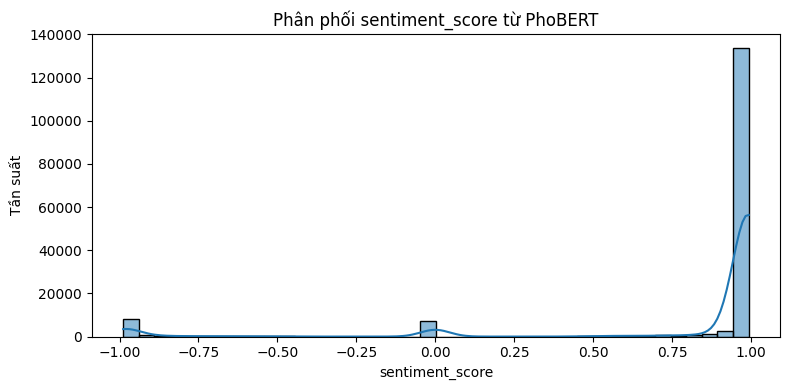

In [8]:
def label_to_signed_score(label: str, confidence: float) -> float:
    label_norm = str(label).lower()
    conf = float(confidence)
    if "pos" in label_norm or "positive" in label_norm:
        return conf
    if "neg" in label_norm or "negative" in label_norm:
        return -conf
    return 0.0


sentiment_df["sentiment_score"] = sentiment_df.apply(
    lambda r: label_to_signed_score(r["sentiment_label"], r["sentiment_confidence"]),
    axis=1,
)
sentiment_df["sentiment_positive"] = (sentiment_df["sentiment_score"] > 0).astype(int)
sentiment_df["sentiment_negative"] = (sentiment_df["sentiment_score"] < 0).astype(int)

summary_sentiment = sentiment_df["sentiment_score"].describe().to_frame("sentiment_score")
display(summary_sentiment)

plt.figure(figsize=(8, 4))
sns.histplot(sentiment_df["sentiment_score"], bins=40, kde=True)
plt.title("Phân phối sentiment_score từ PhoBERT")
plt.xlabel("sentiment_score")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

In [ ]:
if "review_text" in sentiment_df.columns:
    sentiment_preview_df = sentiment_df.copy()
else:
    sentiment_preview_df = sentiment_df.merge(
        df_review[["review_id", "review_text"]],
        on="review_id",
        how="left",
    )

very_negative_reviews = sentiment_preview_df[sentiment_preview_df["sentiment_score"] < -0.9].copy()
very_negative_reviews = very_negative_reviews.sort_values("sentiment_score", ascending=True)

sample_negative = very_negative_reviews[["review_id", "product_id", "sentiment_score", "review_text"]].head(5)
sample_negative

,review_id,product_id,sentiment_score,review_text
95585,20054763,96367806,-0.988398,hàng nhỏ và kém chất lượng. giá hơi cao so với...
91645,16300772,75075591,-0.988371,"đặt sản phẩm h16 mà giao mã h06, sản phẩm đã b..."
125289,11176682,43392570,-0.988370,gởi ốp bị sai chủng loại ko bỏ điện thoại vô d...
155924,7266061,7649718,-0.988369,"sp có chất lượng ko tốt, mối hàng công tắc yếu"
2281,12089520,55583871,-0.988357,đã đổi chế độ nấu cơm trắng thành nấu gạo nứt...


Phân phối sentiment_score cho thấy hiện tượng lệch dương rõ rệt: khối lượng đánh giá mang sắc thái tích cực chiếm ưu thế tuyệt đối, trong khi phần âm và trung tính có tỷ trọng nhỏ. Về mặt nghiên cứu, đây là tín hiệu của thiên lệch hành vi phản hồi và có thể làm suy giảm sức phân biệt của các đặc trưng cảm xúc đơn thuần. Vì vậy, các biến positive_ratio và negative_ratio được giữ lại như chỉ báo cấu trúc cảm xúc ở cấp sản phẩm thay vì chỉ dựa vào một giá trị trung bình.

,Feature,VIF
4,sentiment_mean,152.347
5,positive_ratio,51.795
6,negative_ratio,37.021
1,rating_avg,1.584
2,avg_review_length,1.165
0,log_review_volume,1.135
3,likes_sqrt_adjusted,1.122


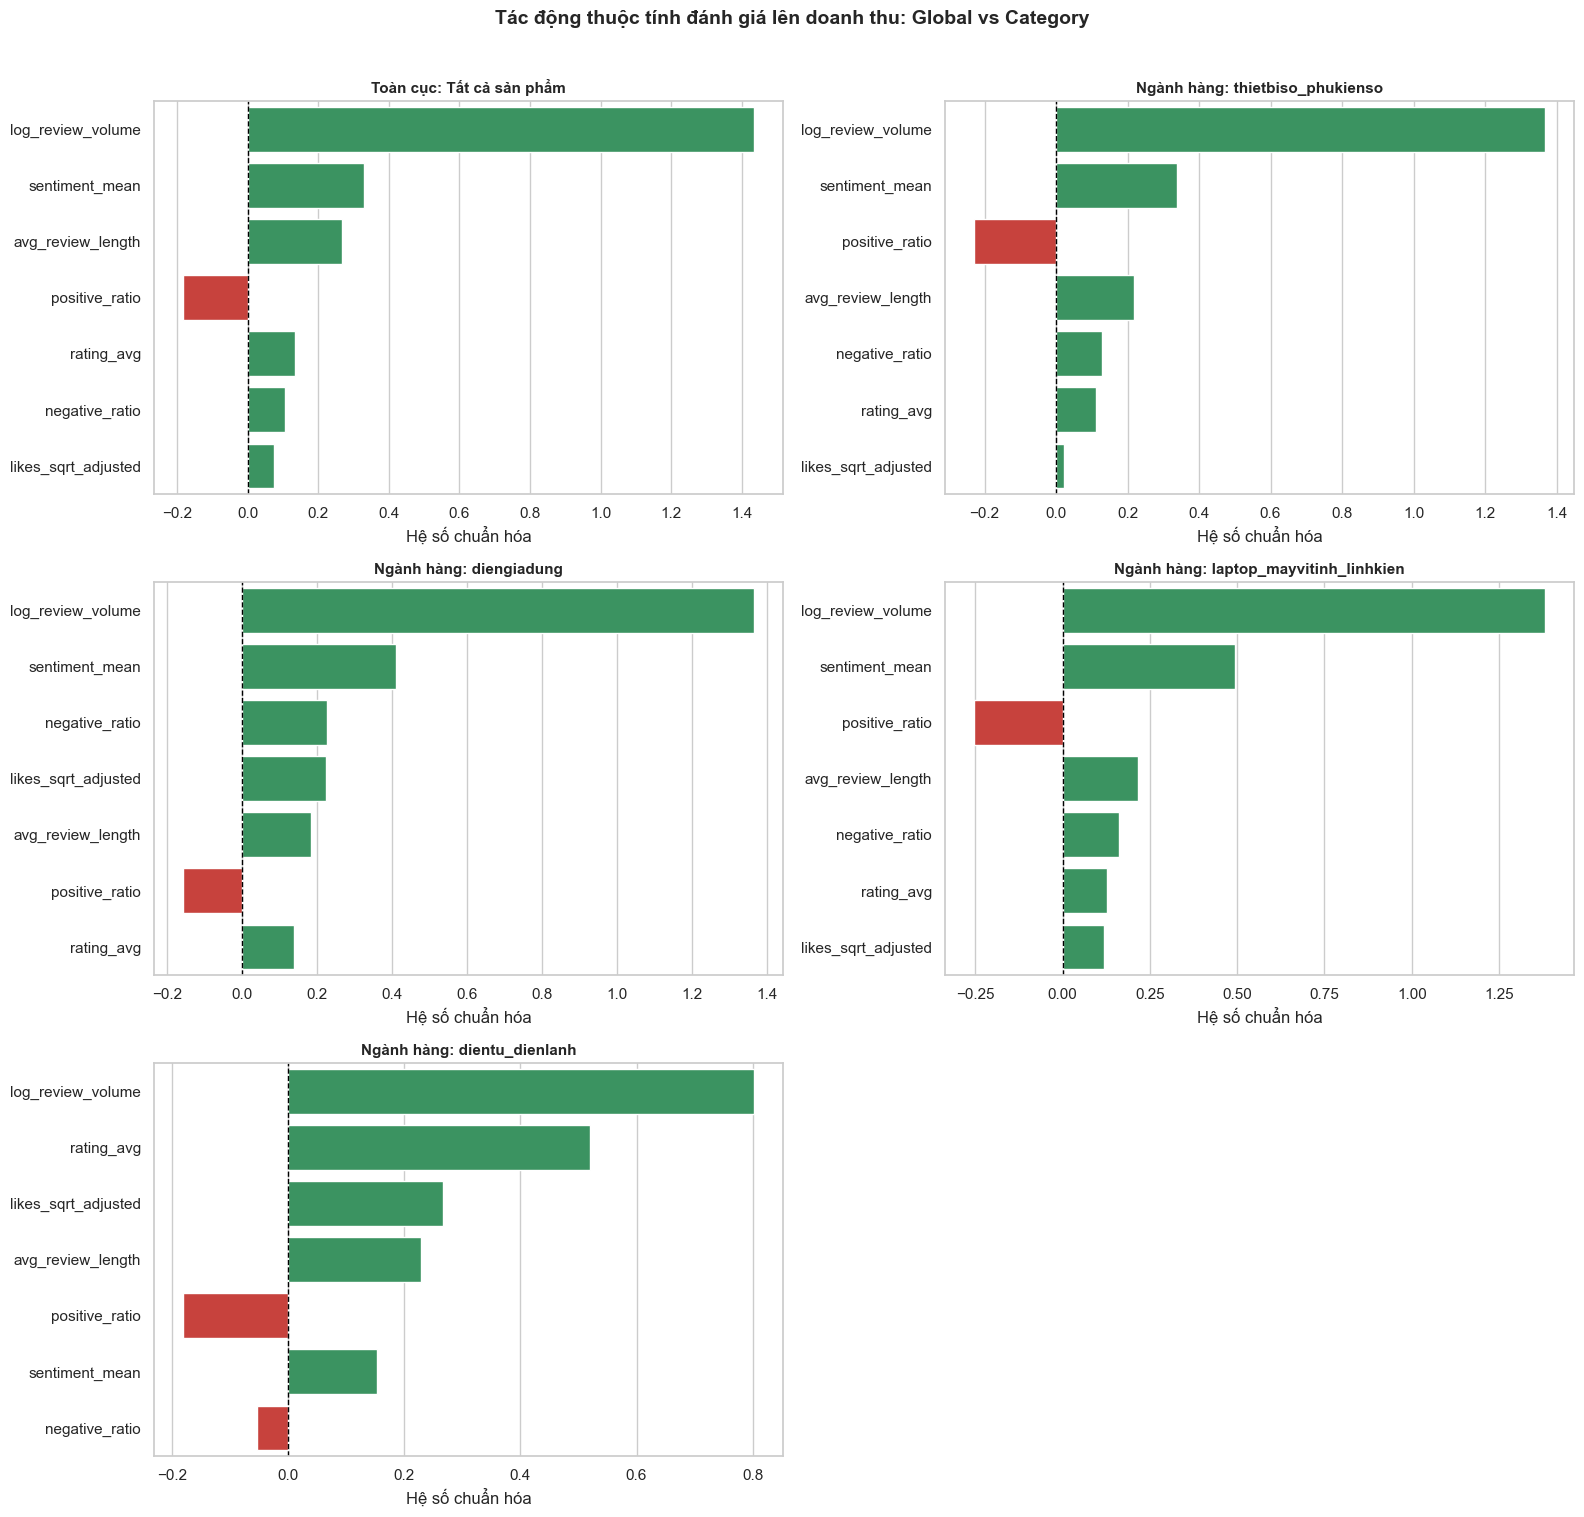

In [11]:
review_df = df_review.copy()
product_df = df_product.copy()

sent_cols = [
    "review_id",
    "sentiment_score",
    "sentiment_positive",
    "sentiment_negative",
]
review_df = review_df.merge(sentiment_df[sent_cols], on="review_id", how="left")
review_df[["sentiment_score", "sentiment_positive", "sentiment_negative"]] = (
    review_df[["sentiment_score", "sentiment_positive", "sentiment_negative"]]
    .fillna(0)
    .astype(float)
)

review_df["product_id"] = review_df["product_id"].astype(str)
product_df["product_id"] = product_df["product_id"].astype(str)

for col in ["price", "sold_count", "rating_avg"]:
    product_df[col] = pd.to_numeric(product_df[col], errors="coerce").fillna(0)

review_df["like_count"] = pd.to_numeric(review_df["like_count"], errors="coerce").fillna(0)
review_df["review_length"] = review_df["review_text"].astype(str).str.len()
product_df["revenue"] = product_df["price"] * product_df["sold_count"]

review_features = review_df.groupby("product_id", as_index=False).agg(
    total_reviews=("review_id", "count"),
    total_review_likes=("like_count", "sum"),
    avg_review_length=("review_length", "mean"),
    sentiment_mean=("sentiment_score", "mean"),
    positive_ratio=("sentiment_positive", "mean"),
    negative_ratio=("sentiment_negative", "mean"),
)

review_features["likes_sqrt_adjusted"] = (
    review_features["total_review_likes"]
    / np.sqrt(review_features["total_reviews"].replace(0, np.nan))
).fillna(0)

df_top_products = product_df.merge(review_features, on="product_id", how="inner")
df_top_products = df_top_products[df_top_products["revenue"] > 0].copy()
df_top_products["L2_ancestor"] = df_top_products["source_category"].fillna("unknown")
df_top_products["log_revenue"] = np.log1p(df_top_products["revenue"])
df_top_products["log_review_volume"] = np.log1p(df_top_products["total_reviews"])

features = [
    "log_review_volume",
    "rating_avg",
    "avg_review_length",
    "likes_sqrt_adjusted",
    "sentiment_mean",
    "positive_ratio",
    "negative_ratio",
]

for c in features:
    df_top_products[c] = pd.to_numeric(df_top_products[c], errors="coerce").fillna(0)


def compute_vif(df, feature_cols):
    vif_rows = []
    for f in feature_cols:
        y_col = df[f].values
        x_cols = [c for c in feature_cols if c != f]
        X = df[x_cols].values
        if X.shape[1] == 0:
            vif_rows.append((f, 1.0))
            continue
        model = LinearRegression()
        model.fit(X, y_col)
        r2 = model.score(X, y_col)
        vif = np.inf if r2 >= 0.999 else 1.0 / (1.0 - r2)
        vif_rows.append((f, vif))
    return pd.DataFrame(vif_rows, columns=["Feature", "VIF"]).sort_values("VIF", ascending=False)


vif_table = compute_vif(df_top_products, features)
display(vif_table.round(3))


def get_linear_weights(df, feature_cols, target_col="log_revenue"):
    X = df[feature_cols]
    y = df[target_col]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LinearRegression()
    model.fit(X_scaled, y)
    out = pd.DataFrame({"Attribute": feature_cols, "Weight": model.coef_})
    out["Impact_Magnitude"] = out["Weight"].abs()
    return out.sort_values("Impact_Magnitude", ascending=False).reset_index(drop=True)


global_weights = get_linear_weights(df_top_products, features)
top1_names = df_top_products["L2_ancestor"].value_counts().head(4).index.tolist()

local_weights_dict = {}
for cat in top1_names:
    df_cat = df_top_products[df_top_products["L2_ancestor"] == cat]
    if len(df_cat) >= 30:
        local_weights_dict[cat] = get_linear_weights(df_cat, features)

sns.set_theme(style="whitegrid")
num_plots = 1 + len(local_weights_dict)
rows, cols = int(np.ceil(num_plots / 2)), 2
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = np.array(axes).reshape(-1)


def plot_weights_on_ax(ax, df_w, title, is_global=False):
    colors = ["#2ca25f" if w > 0 else "#de2d26" for w in df_w["Weight"]]
    sns.barplot(
        data=df_w,
        x="Weight",
        y="Attribute",
        palette=colors,
        hue="Attribute",
        legend=False,
        ax=ax,
    )
    ax.axvline(x=0, color="black", linewidth=1, linestyle="--")
    ax.set_title(title if not is_global else f"Toàn cục: {title}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Hệ số chuẩn hóa")
    ax.set_ylabel("")


plot_weights_on_ax(axes[0], global_weights, "Tất cả sản phẩm", is_global=True)
plot_idx = 1
for cat_name, df_w in local_weights_dict.items():
    plot_weights_on_ax(axes[plot_idx], df_w, f"Ngành hàng: {cat_name}")
    plot_idx += 1
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Tác động thuộc tính đánh giá lên doanh thu: Global vs Category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Kết nối giữa 2 chart ở Câu 2

Chart 1 (Global vs Category coefficients) trả lời câu hỏi **biến nào ảnh hưởng mạnh đến doanh thu** ở cấp sản phẩm.

Chart 2 (Phân tán like theo sentiment và ngành hàng) được thêm để trả lời phần mà Chart 1 chưa thấy được:
- Chart 1 cho ta **độ lớn và chiều tác động trung bình** (mức mô hình).
- Chart 2 cho ta **cơ chế hành vi ở cấp review**: tương tác cộng đồng có tập trung vào review nào, theo sentiment nào, và theo ngành nào.

Vì vậy 2 chart có liên kết theo chuỗi lập luận:
- Chart 1: xác định biến quan trọng (ví dụ: log_review_volume, sentiment, negative_ratio).
- Chart 2: kiểm chứng bối cảnh vi mô khiến các biến đó có tác động khác nhau giữa ngành hàng.

Nếu chỉ dùng 1 chart hồi quy, ta biết "có tác động" nhưng khó giải thích "tại sao tác động khác nhau". Chart 2 giúp củng cố lập luận về bất đối xứng thông tin và hiệu ứng cộng đồng.

### Insight cho người bán để tối ưu doanh thu

- Ưu tiên tăng **review volume chất lượng**: thúc đẩy nhiều review thật, có nội dung cụ thể thay vì review ngắn rập khuôn.
- Quản trị review theo ngành hàng: mỗi ngành có cấu trúc tác động khác nhau, nên kịch bản chăm sóc sau bán cần tách theo ngành, không dùng một mẫu chung.
- Khai thác review tiêu cực có kiểm soát: review negative giàu thông tin thường thu hút tương tác mạnh; phản hồi nhanh và minh bạch sẽ tăng niềm tin và giảm rủi ro mất đơn.
- Tránh “toàn 5 sao chung chung”: tỷ lệ positive quá cực đoan có thể làm giảm độ tin cậy cảm nhận của khách hàng mới.
- Tối ưu nội dung review mục tiêu: gợi ý khách nêu rõ bối cảnh sử dụng, điểm mạnh và điểm chưa tốt để tăng giá trị tham khảo, từ đó cải thiện chuyển đổi mua.

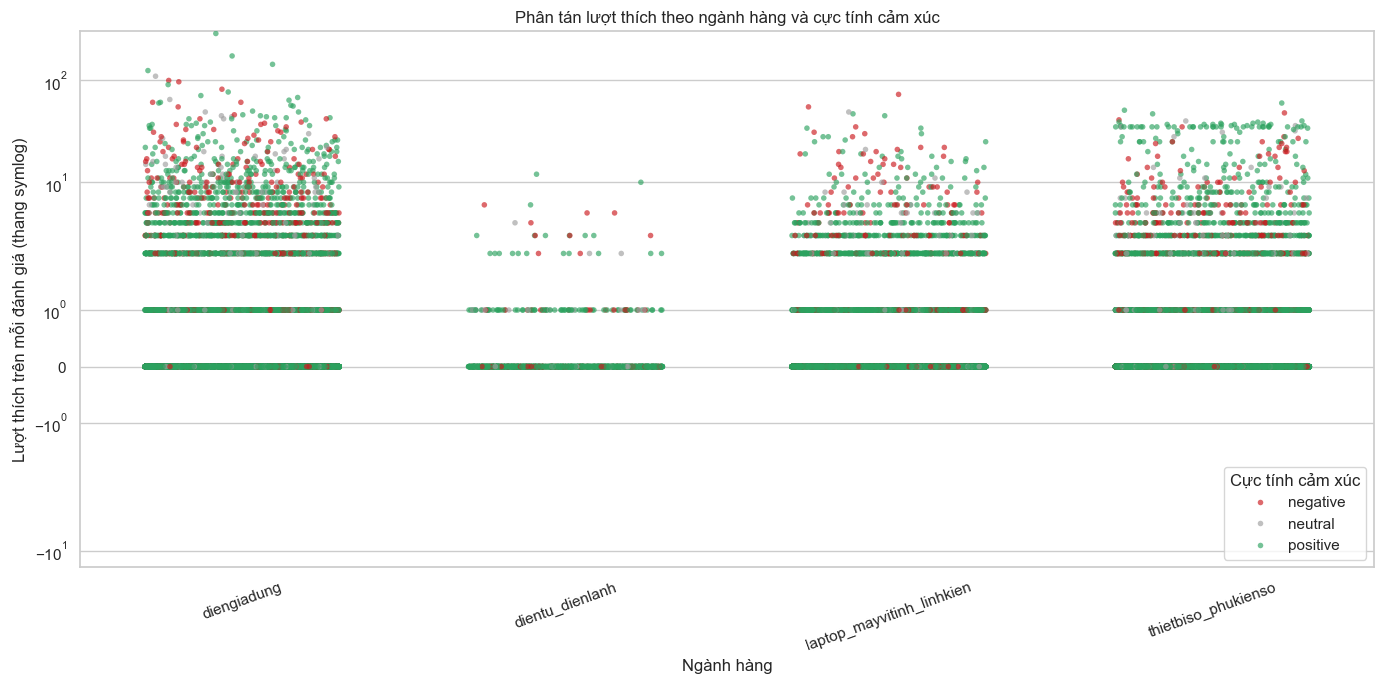

,L2_ancestor,sentiment_side,review_count,median_like,mean_like
2,diengiadung,positive,58394,0.0,0.194712
0,diengiadung,negative,4157,0.0,0.876834
1,diengiadung,neutral,3207,0.0,0.480823
5,dientu_dienlanh,positive,1583,0.0,0.086545
3,dientu_dienlanh,negative,147,0.0,0.333333
4,dientu_dienlanh,neutral,79,0.0,0.253165
8,laptop_mayvitinh_linhkien,positive,17203,0.0,0.209033
6,laptop_mayvitinh_linhkien,negative,1187,0.0,0.920809
7,laptop_mayvitinh_linhkien,neutral,961,0.0,0.399584
11,thietbiso_phukienso,positive,61431,0.0,0.136136


In [13]:
df_review_extended = review_df.merge(
    product_df[["product_id", "source_category"]].rename(columns={"source_category": "product_source_category"}),
    on="product_id",
    how="left",
)
df_review_extended["L2_ancestor"] = df_review_extended["product_source_category"].fillna("unknown")
df_review_extended = df_review_extended[df_review_extended["L2_ancestor"].isin(top1_names)].copy()

df_review_extended["rating"] = pd.to_numeric(df_review_extended["rating"], errors="coerce")
df_review_extended["like_count"] = pd.to_numeric(df_review_extended["like_count"], errors="coerce").fillna(0)

df_review_extended["sentiment_side"] = "neutral"
df_review_extended.loc[df_review_extended["sentiment_positive"] > 0, "sentiment_side"] = "positive"
df_review_extended.loc[df_review_extended["sentiment_negative"] > 0, "sentiment_side"] = "negative"

plot_df = df_review_extended.dropna(subset=["rating"]).copy()
plot_df = plot_df[plot_df["rating"].isin([1, 2, 3, 4, 5])]

plt.figure(figsize=(14, 7))
sns.stripplot(
    data=plot_df,
    x="L2_ancestor",
    y="like_count",
    hue="sentiment_side",
    hue_order=["negative", "neutral", "positive"],
    palette={"negative": "#cb181d", "neutral": "#9e9e9e", "positive": "#2ca25f"},
    dodge=False,
    jitter=0.3,
    alpha=0.65,
    size=4,
)
plt.yscale("symlog")
plt.title("Phân tán lượt thích theo ngành hàng và cực tính cảm xúc")
plt.xlabel("Ngành hàng")
plt.ylabel("Lượt thích trên mỗi đánh giá (thang symlog)")
plt.xticks(rotation=20)
plt.legend(title="Cực tính cảm xúc", loc="lower right")
plt.tight_layout()
plt.show()

category_sentiment_summary = (
    plot_df.groupby(["L2_ancestor", "sentiment_side"])
    .agg(
        review_count=("review_id", "count"),
        median_like=("like_count", "median"),
        mean_like=("like_count", "mean"),
    )
    .reset_index()
    .sort_values(["L2_ancestor", "review_count"], ascending=[True, False])
)

display(category_sentiment_summary)

Phân phối lượt thích ở cấp review tiếp tục thể hiện tính thưa mạnh: đa số quan sát tập trung gần 0, trong khi một số điểm ngoại lai tạo đuôi phân phối dài. Khi tách theo cực tính cảm xúc, nhóm negative có quy mô nhỏ nhưng thường đi kèm các điểm tương tác cao bất thường ở một số ngành, phản ánh vai trò khuếch đại của nội dung cảnh báo trong hành vi cộng đồng.